# Pipeline A — SBERT + UMAP + HDBSCAN

This pipeline performs unsupervised topic discovery on civic complaints using semantic embeddings and density-based clustering. The following steps are performed:

**1. Vectorization with SBERT**: Complaint texts from `df_sbert` are encoded using the `all-mpnet-base-v2` model, producing a 768-dimensional semantic embedding per complaint where semantically similar texts are positioned closer together in vector space. **IMPORTANT: The text embeddings are saved in data/embeddings_sbert.npy. To see the code that produced those embeddings see SbertVectorization.ipynb**

**2. Parameter Selection**: Before applying dimensionality reduction and clustering, a series of empirical tests are conducted to select optimal hyperparameters. An elbow analysis on UMAP information loss determines the optimal number of components, and a sensitivity analysis on HDBSCAN parameters (min_cluster_size and min_samples) using silhouette score and noise rate determines the optimal clustering configuration.

**3. Dimensionality Reduction with UMAP**: The 768-dimensional embeddings are reduced to 20 dimensions using UMAP.

**4. Clustering with HDBSCAN**: HDBSCAN is applied to the 20-dimensional UMAP embeddings to identify dense regions corresponding to semantically coherent complaint groups.

**5. Topic Extraction**: Two complementary methods are applied to each cluster — C-TF-IDF extracts the most representative terms per cluster relative to the entire corpus, and KeyBERT extracts semantically meaningful keyphrases using the same SBERT model used for encoding.

In [12]:
import pandas as pd
df_sbert = pd.read_csv("data/df_sbert.csv")

In [13]:
import numpy as np 

embeddings = np.load('data/embeddings_sbert.npy')
print(embeddings.shape)

(5943, 768)


## Dimensionality Reduction with UMAP

**n_components**: The original 768-dimension vectors are reduced to 20 dimensions, based on the elbow test, where it was the global minimum.

**n_neighbors**: The n_neighbors variable was set to its default value as suggested in UMAP documentation at https://umap-learn.readthedocs.io/en/latest/parameters.html

**min_dist**: min_dist was set to 0.0 to maximize dense cluster regions in the reduced embedding space. Tighter point concentration within semantically similar complaint groups creates more clearly defined high-density regions, enabling HDBSCAN to more reliably distinguish cluster boundaries from noise.

**metric**: Cosine distance was used as the UMAP metric since SBERT embeddings encode semantic meaning in the direction of vectors. Cosine distance measures the angle between vectors, making it more appropriate.

### UMAP Component Selection — Elbow Method

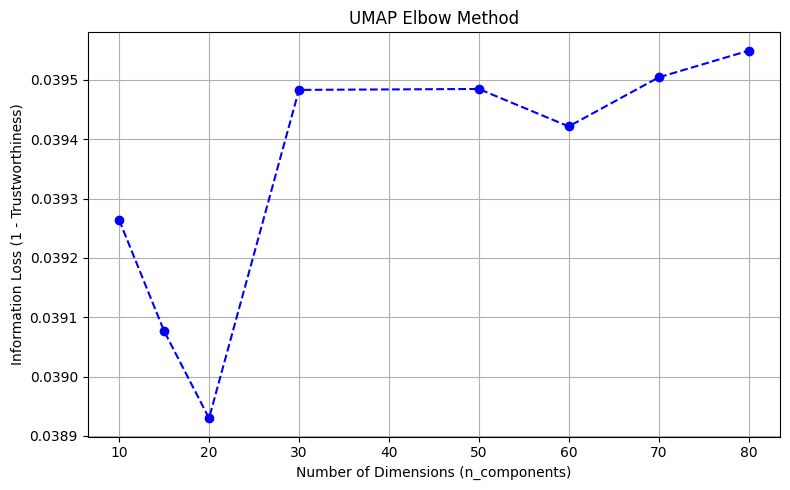

In [16]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import trustworthiness
import umap

data_all = np.load("data/embeddings_sbert.npy").astype(np.float32)
dimensions = [10, 15, 20, 30, 50, 60, 70, 80]
info_loss_scores = []

for dims in dimensions:
    reducer = umap.UMAP(n_components=dims, random_state=42, n_neighbors=15,metric='cosine', low_memory=True)
    reduced_data = reducer.fit_transform(data_all)
    info_loss_scores.append(1 - trustworthiness(data_all, reduced_data, n_neighbors=15))

plt.figure(figsize=(8, 5))
plt.plot(dimensions, info_loss_scores, marker="o", linestyle="--", color="b")
plt.title("UMAP Elbow Method")
plt.xlabel("Number of Dimensions (n_components)")
plt.ylabel("Information Loss (1 - Trustworthiness)")
plt.grid(True)
plt.tight_layout()
plt.show()

### UMAP Reduction 

In [4]:
import warnings
warnings.filterwarnings('ignore')
import umap
import numpy as np


# UMAP 20-dim reduction
reducer = umap.UMAP(
    n_components=20,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
embeddings_umap = reducer.fit_transform(embeddings)
print(f"  Input shape : {embeddings.shape}")
print(f"  Output shape: {embeddings_umap.shape}")


  Input shape : (5943, 768)
  Output shape: (5943, 20)


### Vectorial Space Visualization 

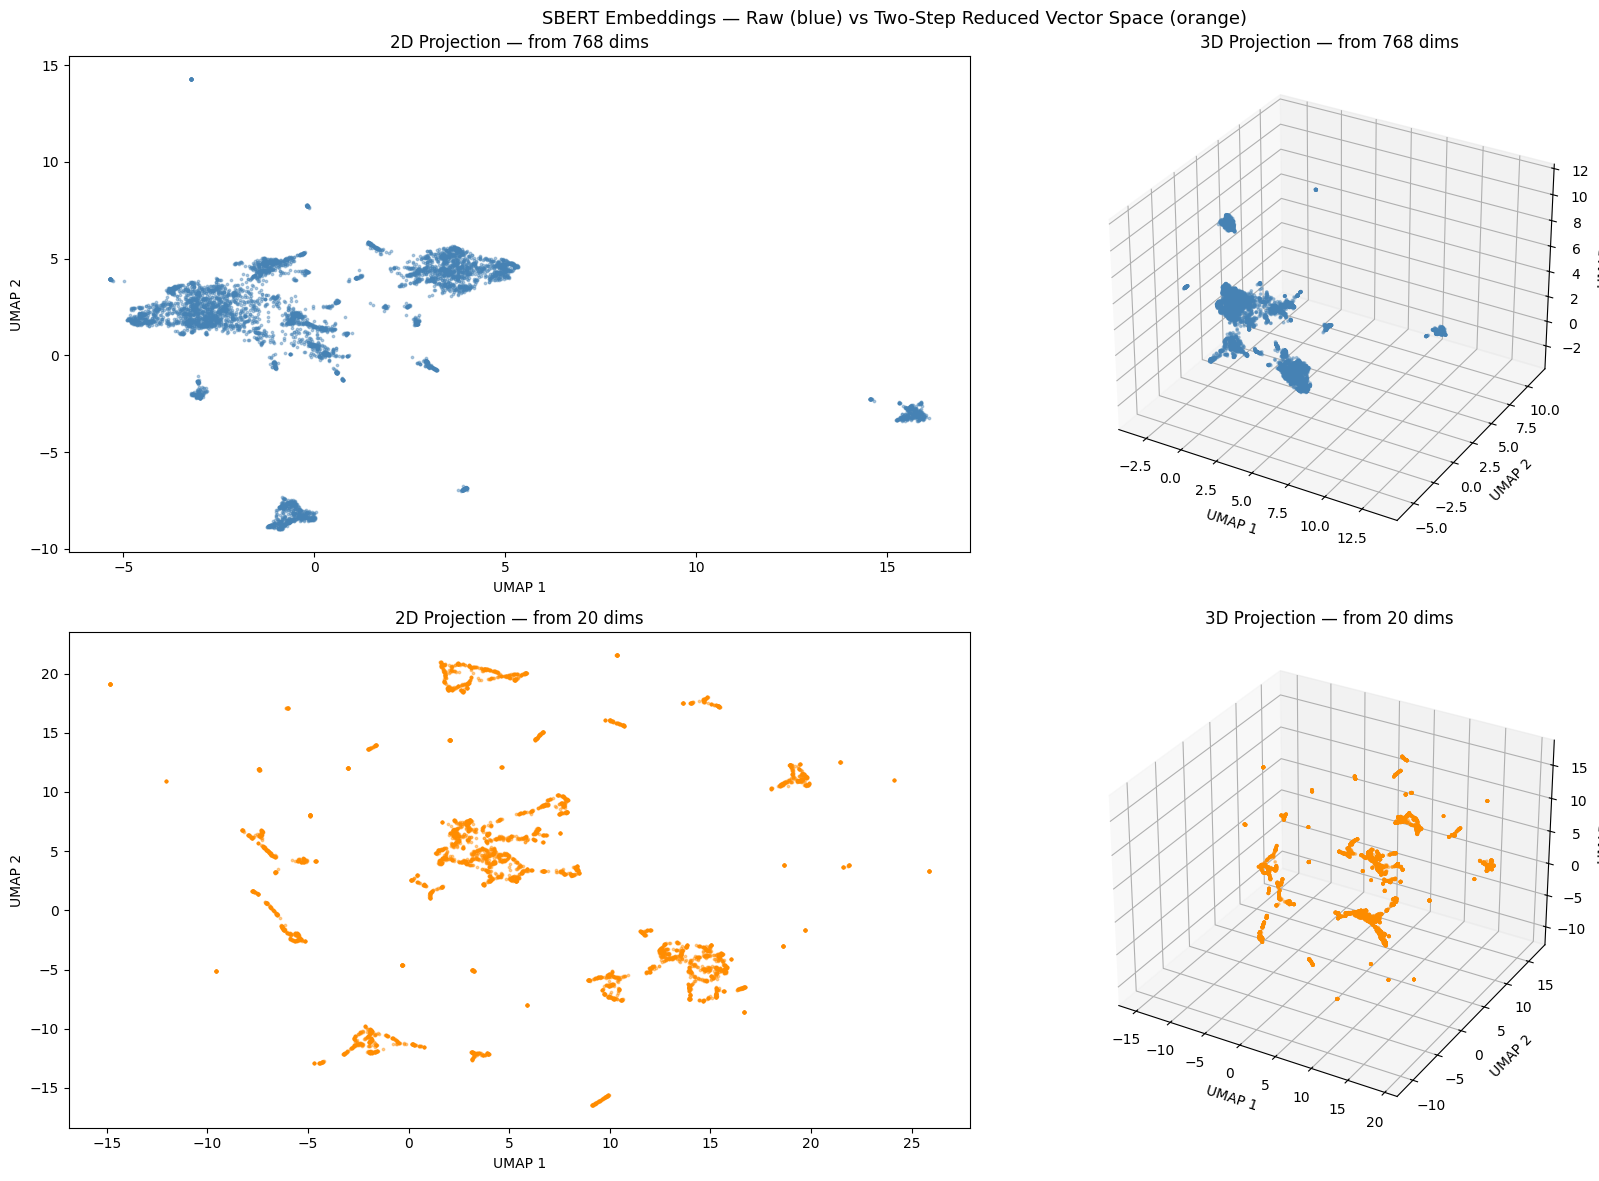

In [5]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# 2D and 3D from original 768
reducer_2d_raw = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
embeddings_2d_raw = reducer_2d_raw.fit_transform(embeddings)

reducer_3d_raw = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
embeddings_3d_raw = reducer_3d_raw.fit_transform(embeddings)

# 2D and 3D from 20-dim
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
embeddings_2d = reducer_2d.fit_transform(embeddings_umap)

reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
embeddings_3d = reducer_3d.fit_transform(embeddings_umap)

# 4 plots
fig = plt.figure(figsize=(18, 12))

# top left — 2D from 768
ax1 = fig.add_subplot(221)
ax1.scatter(embeddings_2d_raw[:, 0], embeddings_2d_raw[:, 1], s=3, alpha=0.4, color='steelblue')
ax1.set_title('2D Projection — from 768 dims')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')

# top right — 3D from 768
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(embeddings_3d_raw[:, 0], embeddings_3d_raw[:, 1], embeddings_3d_raw[:, 2], s=3, alpha=0.4, color='steelblue')
ax2.set_title('3D Projection — from 768 dims')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_zlabel('UMAP 3')

# bottom left — 2D from 20
ax3 = fig.add_subplot(223)
ax3.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=3, alpha=0.4, color='darkorange')
ax3.set_title('2D Projection — from 20 dims')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')

# bottom right — 3D from 20
ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], s=3, alpha=0.4, color='darkorange')
ax4.set_title('3D Projection — from 20 dims')
ax4.set_xlabel('UMAP 1')
ax4.set_ylabel('UMAP 2')
ax4.set_zlabel('UMAP 3')

plt.suptitle('SBERT Embeddings — Raw (blue) vs Two-Step Reduced Vector Space (orange)', fontsize=13)
plt.tight_layout()
plt.show()

## HDBSCAN Parameter Sensitivity Analysis

Two sequential sensitivity tests are conducted to determine the optimal HDBSCAN configuration.

**Test 1 — min_cluster_size**: `min_samples` is fixed at 20 while `min_cluster_size` is varied from 25 to 400. The optimal value is identified as the point where silhouette score peaks before stabilizing.

**Test 2 — min_samples**: `min_cluster_size` is fixed at the optimal value identified in Test 1 while `min_samples` is varied from 5 to 30. The optimal value is selected based on the best silhouette score and noise rate trade-off.

In [7]:
# Test 1

from sklearn.metrics import silhouette_score
import hdbscan

for min_size in [25,50,100, 150, 200, 250, 300, 350,400]:
    c = hdbscan.HDBSCAN(min_cluster_size=min_size, min_samples=20, metric='euclidean')
    l = c.fit_predict(embeddings_umap)
    n_clusters = len(set(l)) - (1 if -1 in l else 0)
    noise = (l == -1).sum()
    score = silhouette_score(embeddings_umap[l != -1], l[l != -1])
    print(f"min_size={min_size} → clusters={n_clusters}, noise={noise/len(l)*100:.1f}%, silhouette={score:.4f}")

min_size=25 → clusters=23, noise=13.3%, silhouette=0.6190
min_size=50 → clusters=10, noise=1.3%, silhouette=0.5276
min_size=100 → clusters=8, noise=0.0%, silhouette=0.5272
min_size=150 → clusters=5, noise=2.0%, silhouette=0.5797
min_size=200 → clusters=5, noise=2.0%, silhouette=0.5797
min_size=250 → clusters=5, noise=2.0%, silhouette=0.5797
min_size=300 → clusters=5, noise=2.0%, silhouette=0.5797
min_size=350 → clusters=4, noise=7.6%, silhouette=0.5564
min_size=400 → clusters=4, noise=7.6%, silhouette=0.5564


In [8]:
# Test 2


from sklearn.metrics import silhouette_score
import hdbscan

for min_s in [5, 10, 15, 20, 25, 30]:
    c = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=min_s, metric='euclidean')
    l = c.fit_predict(embeddings_umap)
    mask = l != -1
    n_clusters = len(set(l)) - (1 if -1 in l else 0)
    noise = (l == -1).sum()
    score = silhouette_score(embeddings_umap[mask], l[mask])
    print(f"min_samples={min_s} → clusters={n_clusters}, noise={noise/len(l)*100:.1f}%, silhouette={score:.4f}")

min_samples=5 → clusters=5, noise=2.4%, silhouette=0.5856
min_samples=10 → clusters=5, noise=2.0%, silhouette=0.5796
min_samples=15 → clusters=5, noise=2.0%, silhouette=0.5797
min_samples=20 → clusters=5, noise=2.0%, silhouette=0.5797
min_samples=25 → clusters=5, noise=2.2%, silhouette=0.5807
min_samples=30 → clusters=5, noise=2.1%, silhouette=0.5805


## Clustering with HDBSCAN

**min_cluster_size**: min_cluster variable was set to be 200 since the silhouette score peaks at this point and stablizes, as shown in the latter test results.

**min_samples**: Although min_samples=25 produced a higher silhouette score, it came at the cost of a noise rate of 7.5%. Therefore, min_samples=20 was selected as it achieves the best silhouette score and noise lose trade of among all tested values.

**metric**: Euclidean distance was used for HDBSCAN since the prior UMAP reduction to 20 dimensions produces a compact embedding space where Euclidean distance becomes geometrically meaningful.

**cluster_selection_method**: The Excess of Mass (EOM) method was selected for cluster extraction as it identifies clusters at varying levels of the cluster hierarchy, producing broader and semantically meaningful topic groups. The alternative leaf method forces selection of the smallest clusters at the bottom of the hierarchy, which would over-fragment complaint topics. As mentioned in https://hdbscan.readthedocs.io/en/latest/parameter_selection.html

**Remaining parameters**: The rest of HDBSCAN parameters (alpha & cluster_selection_epsilon) were left as default as recommended by the official documentation.

  Clusters found    : 5
  Noise points      : 119 (2.0%)


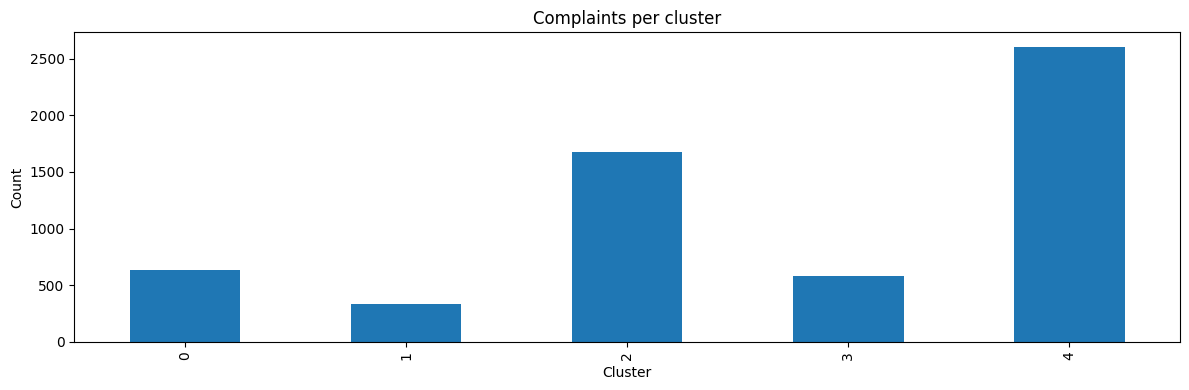

In [9]:
import warnings
warnings.filterwarnings('ignore')
import hdbscan
import matplotlib.pyplot as plt

## Running HDBSCAN clustering 
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=20,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels = clusterer.fit_predict(embeddings_umap)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"  Clusters found    : {n_clusters}")
print(f"  Noise points      : {n_noise} ({n_noise/len(labels)*100:.1f}%)")

df_sbert['cluster'] = labels

cluster_counts = df_sbert[df_sbert['cluster'] != -1]['cluster'].value_counts().sort_index()
plt.figure(figsize=(12, 4))
cluster_counts.plot(kind='bar')
plt.title('Complaints per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Topic Extraction

After obtaining 5 distinct clusters, topic extraction was performed using two methods: 
C-TF-IDF and KeyBERT. Both methods returned consistent results, although KeyBERT produced 
slightly more precise distinctions for clusters 3 and 4. The interpretability of the 
results with both methods is excellent, and the clear topic distinction across clusters 
validates the quality of the HDBSCAN clustering pipeline.
## Discovered Semantic Topics

| Cluster | Topic |
|---|---|
| 0 | Stray Dogs |
| 1 | Public Street Lighting |
| 2 | Garbage & Waste Dumping |
| 3 | Sewage & Drainage Problems |
| 4 | Damaged Roads|

###  C-TF-IDF Topic Extraction

In [10]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# combine all samples per cluster into one document per cluster
cluster_docs = {}
for cluster_id in sorted(df_sbert['cluster'].unique()):
    if cluster_id == -1:
        continue
    texts = df_sbert[df_sbert['cluster'] == cluster_id]['text_sbert'].tolist()
    cluster_docs[cluster_id] = " ".join(texts)

# fit TF-IDF treating each cluster as one document
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2)) # allow single words and two-word phrases as topics
tfidf_matrix = vectorizer.fit_transform(list(cluster_docs.values()))
feature_names = vectorizer.get_feature_names_out()

# extract top 5 terms per cluster
ctfidf_results = {}
rows = []
for idx, cluster_id in enumerate(sorted(cluster_docs.keys())):
    row = tfidf_matrix[idx].toarray()[0]
    top_indices = row.argsort()[-5:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    ctfidf_results[cluster_id] = top_terms
    rows.append({
        'Cluster': cluster_id,
        'Size': (df_sbert['cluster'] == cluster_id).sum(),
        'Top Terms (C-TF-IDF)': ', '.join(top_terms)
    })

df_ctfidf = pd.DataFrame(rows)
display(df_ctfidf.style.hide(axis='index'))

Cluster,Size,Top Terms (C-TF-IDF)
0,630,"street, lights, street lights, working, light"
1,334,"dogs, stray, stray dogs, night, barking"
2,1678,"garbage, road, people, bbmp, area"
3,581,"water, road, drainage, sewage, water supply"
4,2601,"road, roads, main, condition, footpath"


### KeyBert Topic extraction

In [11]:
import warnings
warnings.filterwarnings('ignore')
from keybert import KeyBERT
import pandas as pd

# load keybert 
kw_model = KeyBERT(model='all-mpnet-base-v2')

keybert_results = {}
rows = []
# sample 300 complaints per cluster to ensure balanced representation across clusters
for cluster_id in sorted(cluster_docs.keys()):
    texts = df_sbert[df_sbert['cluster'] == cluster_id]['text_sbert'].sample(
        min(30, len(df_sbert[df_sbert['cluster'] == cluster_id])),
        random_state=42
    ).tolist()
    
    combined = " ".join(texts)[:4000] #read the first 4000 characters of each sample

    keywords = kw_model.extract_keywords(
        combined,
        keyphrase_ngram_range=(1, 2),  # allow single words and two-word phrases as topics
        stop_words='english',
        top_n=5
    )
    keybert_results[cluster_id] = [kw[0] for kw in keywords]
    rows.append({
        'Cluster': cluster_id,
        'Size': (df_sbert['cluster'] == cluster_id).sum(),
        'Top Keywords (KeyBERT)': ', '.join([kw[0] for kw in keywords]),
    })

df_keybert = pd.DataFrame(rows)
display(df_keybert.style.hide(axis='index'))

Cluster,Size,Top Keywords (KeyBERT)
0,630,"connecting harinagar, lights difficult, road lights, lights road, fix street"
1,334,"stray dogs, problem stray, diseases stray, stray dog, dogs pls"
2,1678,"collect garbage, garbage building, clean street, dumping garbage, dump garbage"
3,581,"sewage overflow, sewage overflowing, badly drainage, drainage blocked, houses drainage"
4,2601,"potholes repaired, road venkateshwara, repair roads, roads dugged, road request"
